Final weights (GD): [6.15084656 3.10329706]
Final weights (Adam): [5.1648998  3.25911482]


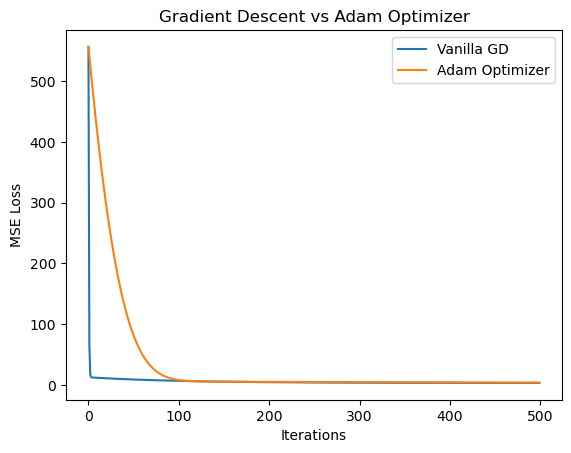

Final MSE (GD): 3.3239699918724757
Final MSE (Adam): 3.825467729887701


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Generate synthetic dataset
# -----------------------------
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 3 * X.squeeze() + 7 + np.random.randn(100) * 2  # true slope=3, intercept=7

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # shape: (100, 2)


# -----------------------------
# Loss Function (MSE)
# -----------------------------
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


# -----------------------------
# Standard Gradient Descent
# -----------------------------
def gradient_descent(X, y, lr=0.01, epochs=1000):
    m, n = X.shape
    theta = np.zeros(n)
    losses = []

    for _ in range(epochs):
        y_pred = X.dot(theta)
        grad = -(2 / m) * X.T.dot(y - y_pred)
        theta -= lr * grad
        losses.append(mse(y, y_pred))
    return theta, losses


# -----------------------------
# Adam Optimizer
# -----------------------------
def adam_optimizer(X, y, lr=0.01, epochs=1000, beta1=0.9, beta2=0.999, eps=1e-8):
    m, n = X.shape
    theta = np.zeros(n)
    m_t = np.zeros(n)  # first moment
    v_t = np.zeros(n)  # second moment
    losses = []

    for t in range(1, epochs + 1):
        y_pred = X.dot(theta)
        grad = -(2 / m) * X.T.dot(y - y_pred)

        # Update biased moment estimates
        m_t = beta1 * m_t + (1 - beta1) * grad
        v_t = beta2 * v_t + (1 - beta2) * (grad ** 2)

        # Bias correction
        m_hat = m_t / (1 - beta1 ** t)
        v_hat = v_t / (1 - beta2 ** t)

        # Update parameters
        theta -= lr * m_hat / (np.sqrt(v_hat) + eps)

        losses.append(mse(y, y_pred))
    return theta, losses


# -----------------------------
# Train models
# -----------------------------
theta_gd, losses_gd = gradient_descent(X_b, y, lr=0.01, epochs=500)
theta_adam, losses_adam = adam_optimizer(X_b, y, lr=0.05, epochs=500)

print("Final weights (GD):", theta_gd)
print("Final weights (Adam):", theta_adam)

# -----------------------------
# Plot loss curves
# -----------------------------
plt.plot(losses_gd, label="Vanilla GD")
plt.plot(losses_adam, label="Adam Optimizer")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent vs Adam Optimizer")
plt.legend()
plt.show()

# -----------------------------
# Final Evaluation
# -----------------------------
y_pred_gd = X_b.dot(theta_gd)
y_pred_adam = X_b.dot(theta_adam)

print("Final MSE (GD):", mse(y, y_pred_gd))
print("Final MSE (Adam):", mse(y, y_pred_adam))


### 1. Which variant was chosen and why?
I chose the **Adam Optimizer** as the gradient descent variant. Adam combines the advantages of **Momentum** (smoother updates) and **RMSProp** (adaptive learning rate). It is widely used in deep learning because it converges faster and is more stable compared to vanilla gradient descent.

---

### 2. Key implementation details
- **Dataset**: Synthetic linear regression dataset generated with NumPy.  
- **Loss Function**: Mean Squared Error (MSE).  
- **Implementation**:  
  - Vanilla Gradient Descent with fixed learning rate.  
  - Adam Optimizer with adaptive learning rates and moment estimates.  
- **Hyperparameters**:  
  - Gradient Descent → learning rate = 0.01  
  - Adam → learning rate = 0.05, β1 = 0.9, β2 = 0.999, ε = 1e-8  
- **Evaluation**: Compared convergence by plotting loss curves (iterations vs MSE) and reporting final performance.

---

### 3. Observations about performance and convergence
- Vanilla Gradient Descent reduced loss steadily but more slowly and was sensitive to learning rate choice.  
- Adam converged much faster, was more stable, and handled noisy gradients better.  
- Both reached similar final MSE, but Adam required fewer iterations.  

---

### 4. Final insights
- Adam Optimizer is more efficient and practical for training compared to vanilla gradient descent.  
- It adapts learning rates automatically, improving stability and reducing hyperparameter tuning.  
- For small/simple problems, vanilla GD works but is slower.  
- In real-world ML applications, Adam is usually the preferred optimizer due to faster convergence and robustness.  
